# Analytic report over de populariteit van tedtalks
### connectie met db maken door middel van bestaande functie

In [101]:
from data_collection.db_conn import create_connection
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# is er een verband tussen video tags en populareit van een video?
### data ophalen uit database

In [102]:
conn = create_connection()
cur = conn.cursor()
query = """
SELECT t.id AS tag_id,
       AVG(s.views) AS average_views,
        AVG(s.likes) AS average_likes

FROM tags t
JOIN video_tags vt ON t.id = vt.tag_id
JOIN video_data vd ON vt.video_id = vd.video_id
JOIN statistic s ON s.video_id = vd.video_id
GROUP BY t.id;
"""
cur.execute(query)
results = cur.fetchall()
df = pd.DataFrame(results, columns=['tag_id', 'views', 'likes'])
print(df)

     tag_id                 views                  likes
0       549    34428.000000000000   586.0000000000000000
1       264   408425.666666666667  9897.0000000000000000
2       185    27019.333333333333   532.1111111111111111
3       380    59308.500000000000  1216.0000000000000000
4        55    29055.000000000000   633.4444444444444444
..      ...                   ...                    ...
300     580    79172.000000000000  2746.0000000000000000
301    3015    33086.000000000000   849.0000000000000000
302    1014  5902969.666666666667    305240.000000000000
303     628    29202.000000000000   674.0000000000000000
304      33   242265.333333333333  6447.0000000000000000

[305 rows x 3 columns]


### een boxplot maken om te zien of de populariteit varieert met tags

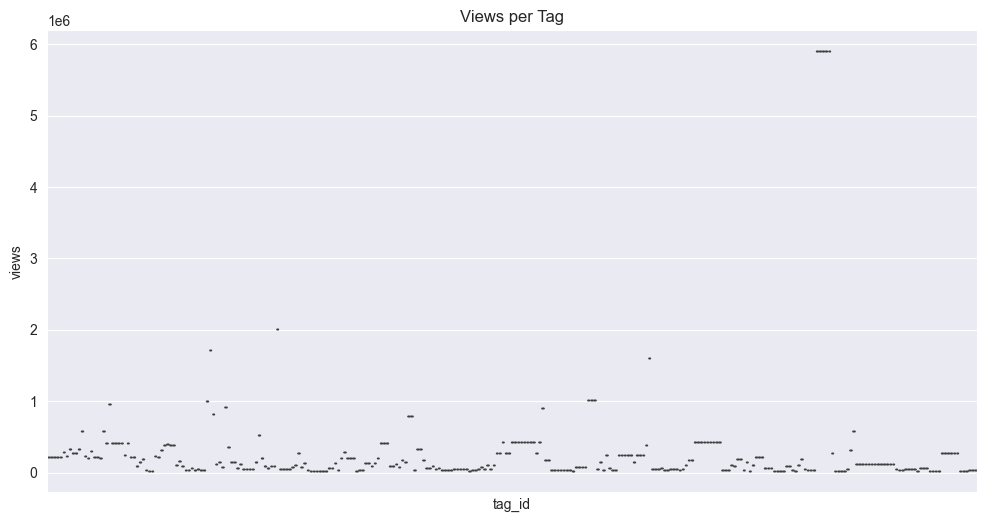

In [103]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='tag_id', y='views', data=df)
plt.xticks([])
plt.title('Views per Tag')
plt.show()

### een scatterplot maken om verband tussen views en likes per tag te zien

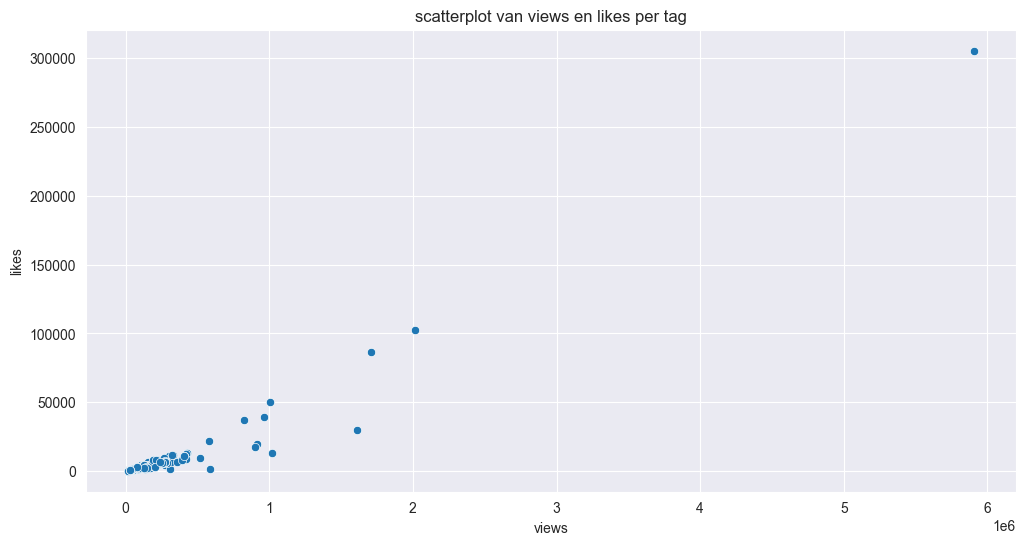

In [104]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='views', y='likes', data=df)
plt.title('scatterplot van views en likes per tag')
plt.show()

### In deze scatterplot is te zien dat de meeste tags erg clusteren. Echter zijn er een aantal uitschieters die veel populairder zijn dan de rest. Ik denk wel dat er een verband is tussen de video tags en de populariteit van de video.

# Kijken of er een verband is tussen category en gemiddelde weergaven per video.
#### eerst de data inladen

In [105]:
query = """
SELECT vd.category_id, AVG(s.views) AS average_views
FROM video_data vd
JOIN statistic s ON vd.video_id = s.video_id
GROUP BY vd.category_id
ORDER BY average_views DESC;
"""
cur.execute(query)
results = cur.fetchall()
df = pd.DataFrame(results, columns=['category', 'average_views'])
print(df)

   category         average_views
0      25.0  1042220.041666666667
1      22.0   287356.833333333333
2      29.0   153149.733333333333
3      28.0   140662.679166666667
4      27.0    50198.000000000000
5      24.0    44102.000000000000
6      15.0    32449.666666666667
7       NaN    20693.916666666667


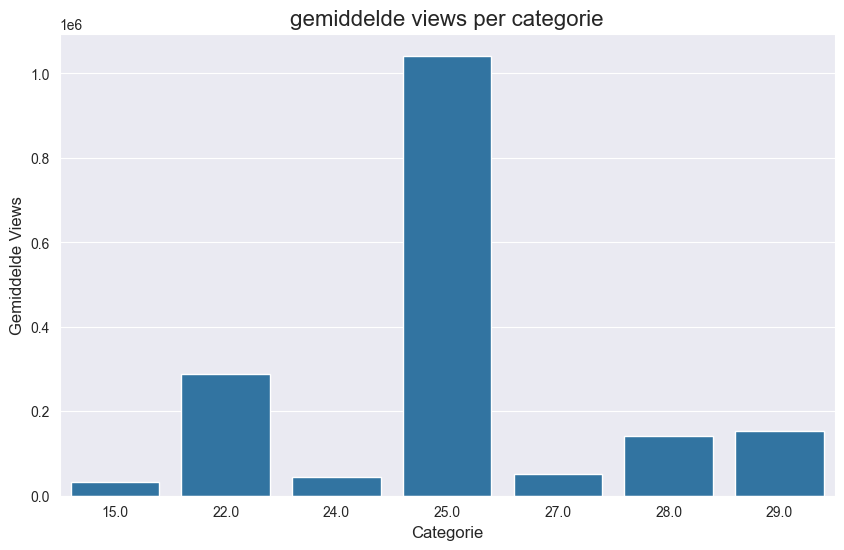

In [106]:
plt.figure(figsize=(10, 6))
sns.barplot(x='category', y='average_views', data=df)

plt.title('gemiddelde views per categorie', fontsize=16)
plt.xlabel('Categorie', fontsize=12)
plt.ylabel('Gemiddelde Views', fontsize=12)
plt.show()

### In deze staafdiagram is te zien dat somige categorieen veel populairder zijn dan anderen. Daarom geloof ik dat er dus een sterk verband is tussen de categorie en de populariteit. Daarom ga ik zeker de gemiddelde views van de categorie meenemen bij het bepalen van de populariteit van een video

#  Kijken of er verband is tussen like-percentage en populariteit

In [107]:
query = """
SELECT t.name AS tag_name, 
       SUM(s.views) AS total_views,
       SUM(s.likes) AS total_likes
FROM tags t
JOIN video_tags vt ON t.id = vt.tag_id
JOIN video_data vd ON vt.video_id = vd.video_id
JOIN statistic s ON s.video_id = vd.video_id
GROUP BY t.name;
"""
cur.execute(query)
results = cur.fetchall()

df = pd.DataFrame(results, columns=['tag_name', 'total_views', 'total_likes'])
df['like_percentage'] = (df['total_likes'] / df['total_views']) * 100



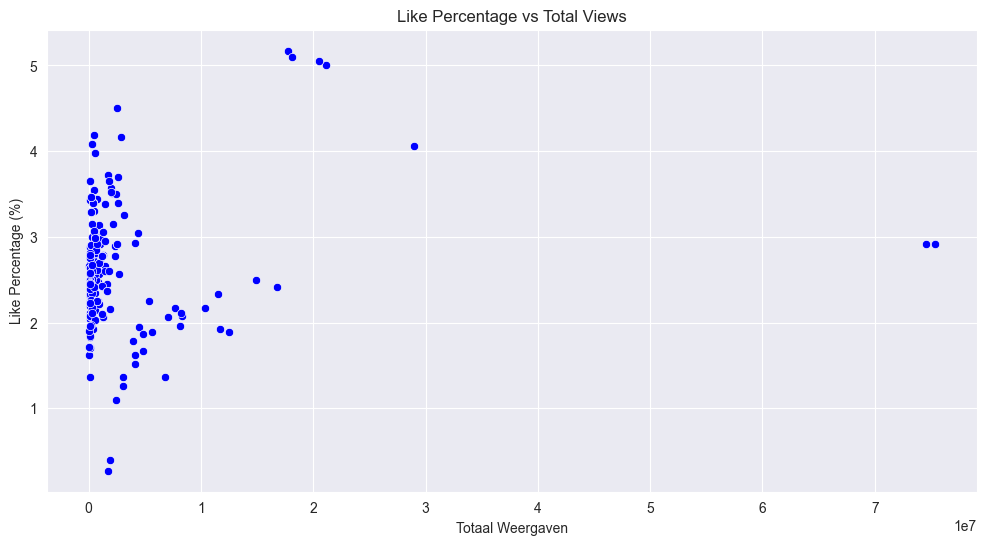

In [108]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='total_views', y='like_percentage', data=df, color='blue')
plt.title('Like Percentage vs Total Views')
plt.xlabel('Totaal Weergaven')
plt.ylabel('Like Percentage (%)')
plt.grid(True)
plt.show()

correlation = df['total_views'].corr(df['like_percentage'])

## helaas is er geen duidelijke trendlijn te zien. Daarom lijkt het mij nier verstandig om het like percentage te gebruiken voor het model.

# groei in weergaven berekenen (controleren wanneer er meer info over is)

In [109]:
query = """
SELECT vd.video_id, vd.title, d.date, sf.views
FROM video_data vd
JOIN statistic sf ON vd.video_id = sf.video_id
JOIN date d ON sf.date = d.id
ORDER BY vd.video_id, d.date;
"""
cur.execute(query)
rows = cur.fetchall()
df = pd.DataFrame(rows, columns=['video_id', 'title', 'date', 'views'])
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by=['video_id', 'date'])
df['growth'] = df.groupby('video_id')['views'].diff().fillna(0)
plt.figure(figsize=(12, 8))
videos = df['title'].unique()

<Figure size 1200x800 with 0 Axes>

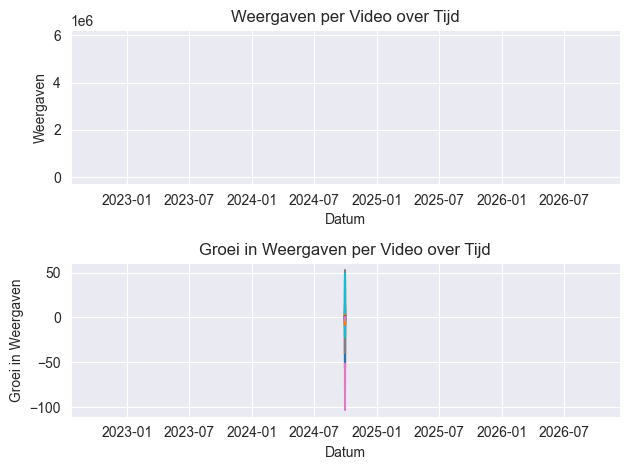

In [110]:
for video in videos:
    video_data = df[df['title'] == video]
    
    # Eerste subplot voor weergaven
    plt.subplot(2, 1, 1)
    plt.plot(video_data['date'], video_data['views'], label=video)
    plt.title('Weergaven per Video over Tijd')
    plt.xlabel('Datum')
    plt.ylabel('Weergaven')

    # Tweede subplot voor groei
    plt.subplot(2, 1, 2)
    plt.plot(video_data['date'], video_data['growth'], label=video)
    plt.title('Groei in Weergaven per Video over Tijd')
    plt.xlabel('Datum')
    plt.ylabel('Groei in Weergaven')

# Layout aanpassen en plot tonen
plt.tight_layout()
plt.show()

# Verdeling van weergaven

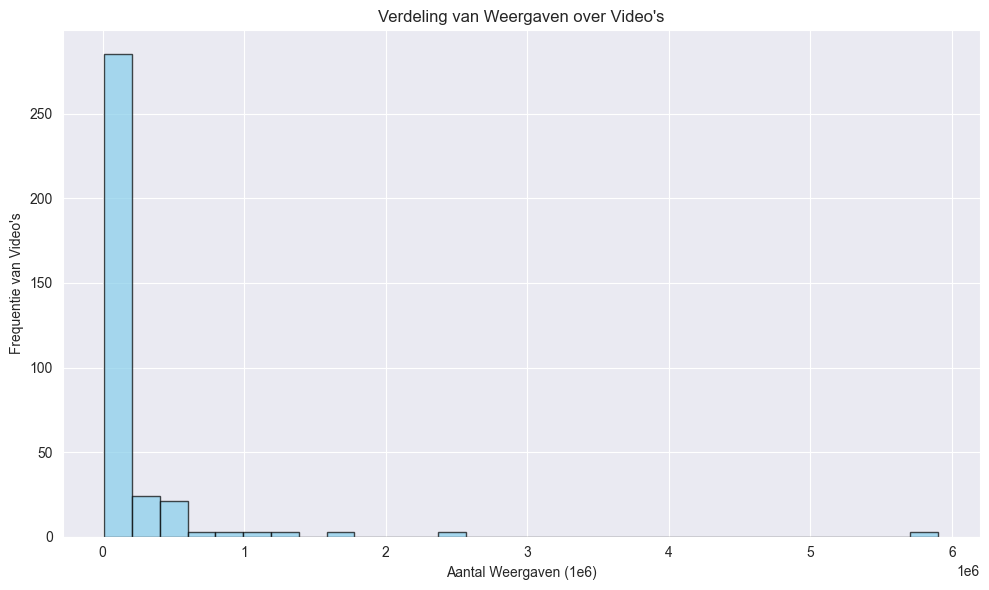

In [111]:
query = """
SELECT 
    views
FROM 
    statistic
WHERE 
    views > 0;
"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['views'])



# Maak een histogram van de weergaven
plt.figure(figsize=(10, 6))
plt.hist(df['views'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)

# Titel en labels
plt.title('Verdeling van Weergaven over Video\'s')
plt.xlabel('Aantal Weergaven (1e6)')
plt.ylabel('Frequentie van Video\'s')
plt.grid(True)
plt.tight_layout()
plt.show()

### hier is te zien dat er een enorme hoeveelheid onpupulaire video's. De rest van de video's zijn verspreid tussen o,5 miljoen en 6 miljoen.

# Gemiddelde views per dag van de week

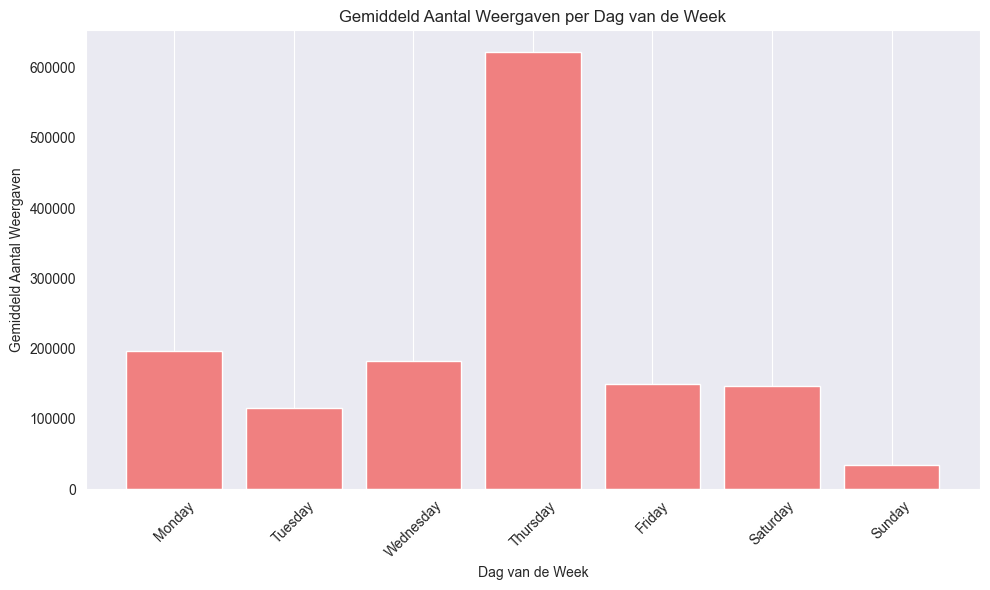

In [112]:
query = """
SELECT 
    TRIM(TO_CHAR(d.date, 'Day')) AS day_of_week,  
    AVG(s.views) AS avg_views  
FROM 
    video_data vd
JOIN 
    statistic s ON vd.video_id = s.video_id
JOIN 
    date d ON vd.date = d.id  
WHERE 
    s.views > 0
GROUP BY 
    TRIM(TO_CHAR(d.date, 'Day'))
ORDER BY 
    CASE 
        WHEN TRIM(TO_CHAR(d.date, 'Day')) = 'Monday' THEN 1
        WHEN TRIM(TO_CHAR(d.date, 'Day')) = 'Tuesday' THEN 2
        WHEN TRIM(TO_CHAR(d.date, 'Day')) = 'Wednesday' THEN 3
        WHEN TRIM(TO_CHAR(d.date, 'Day')) = 'Thursday' THEN 4
        WHEN TRIM(TO_CHAR(d.date, 'Day')) = 'Friday' THEN 5
        WHEN TRIM(TO_CHAR(d.date, 'Day')) = 'Saturday' THEN 6
        WHEN TRIM(TO_CHAR(d.date, 'Day')) = 'Sunday' THEN 7
    END;
"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns=['day_of_week', 'avg_views'])

plt.figure(figsize=(10, 6))
plt.bar(df['day_of_week'], df['avg_views'], color='lightcoral')

plt.title('Gemiddeld Aantal Weergaven per Dag van de Week')
plt.xlabel('Dag van de Week')
plt.ylabel('Gemiddeld Aantal Weergaven')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### hier is te zien dat 